# DemoMA_MCClassification_CCGPFL_GPyTorch

### This demo shows an example of Multi-class classification with multiple annotators by using our model based on correlated chained Gaussian processes for multiple annotators with focal loss (CCGGFL).

In [1]:
!pip install -q gpytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 17.2 MB/s eta 0:00:00


In [2]:
import sys
from functools import partial
import warnings
import os
sys.path.append('..')

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.metrics.cluster import normalized_mutual_info_score

import math
import torch
from torch import Tensor

import gpytorch
from gpytorch.likelihoods import Likelihood
from gpytorch.distributions import base_distributions, MultitaskMultivariateNormal
from gpytorch.utils.quadrature import GaussHermiteQuadrature1D

import matplotlib.pyplot as plt
import random
random.seed(100)

import tqdm
from matplotlib import pyplot as plt


In [3]:
# Clone the repo containig useful functions and the model
!git clone https://github.com/juliangilg/CCGPCR.git
sys.path.append('/content/CCGPCR')

Cloning into 'CCGPCR'...
remote: Enumerating objects: 46, done.
remote: Counting objects: 100% (46/46), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 46 (delta 24), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (46/46), 277.75 KiB | 3.61 MiB/s, done.
Resolving deltas: 100% (24/24), done.


In [4]:
# Loading useful funtions
from utils import *
from ccgpfl_gpytorch import MultiClassMA, MultitaskGPModel,build_ccgpma

/content/CCGPCR/utils.py:44: SyntaxWarning: invalid escape sequence '\c'
  1. For each annotator $r$, we compute a function $f_r(\cdot)$ as a combination


## 1. Multi-class classification problem definition

We assume a 1D multi-class classification problem, where input features are given as $x \in [0, 1]$ and the outputs are generated as follows

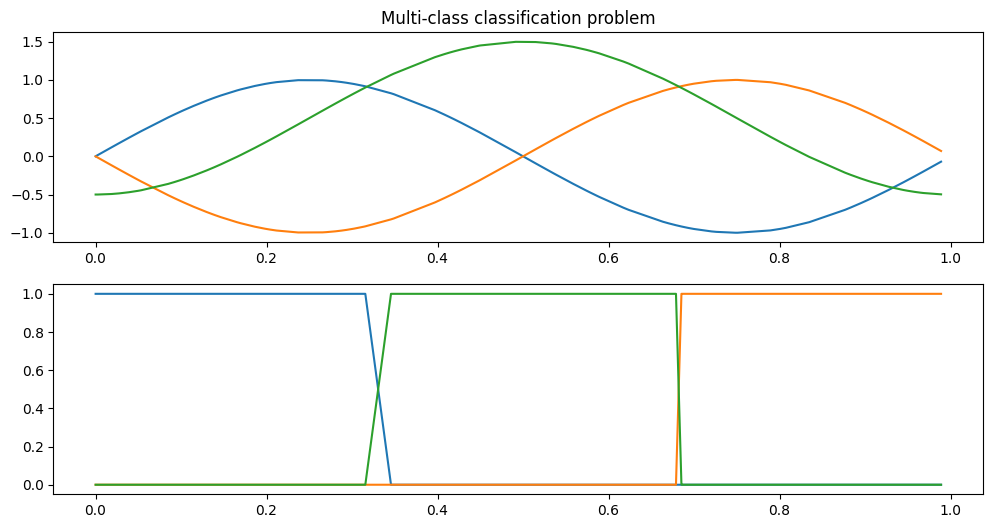

In [5]:
N = 100

np.random.seed(1)
X = np.random.rand(N,1)

t1 = (np.sin(2*np.pi*X)).reshape(N,1)
t2 = (-np.sin(2*np.pi*X)).reshape(N,1)
t3 = (-np.sin(2*np.pi*(X+0.25))+0.5).reshape(N,1)
t = np.concatenate((t1, t2, t3), axis=1)

idx = np.argsort(X, axis=0).flatten()
X = X[idx]
t = t[idx,:]
y = np.array(np.argmax(t, 1).reshape(-1,1), dtype=float)+1
K = len(np.unique(y))

# The true labels in codification 1-of-K
Yhat = one_of_K(y, K)

plt.figure(figsize=(12,6))
plt.subplot(2,1,1)
plt.plot(X, t)
plt.title('Multi-class classification problem')
plt.subplot(2,1,2)
plt.plot(X, Yhat)
plt.show()

To define the training set, we randomly obtain $N=100$ samples from the interval $[0, 1]$. Conversely, for the test set, we sample uniformly $200$ points from $[0, 1]$

In [6]:
seed = 1
np.random.seed(seed)
Ntest = 200

# The training set
Xtrain = X
Xtrain = Xtrain.reshape((N,1))
ytrain = y

# The test set
Xtest = np.linspace(0, 1, Ntest).reshape((Ntest,1))
t1 = (np.sin(2*np.pi*Xtest)).reshape(Ntest,1)
t2 = (-np.sin(2*np.pi*Xtest)).reshape(Ntest,1)
t3 = (-np.sin(2*np.pi*(Xtest+0.25))+0.5).reshape(Ntest,1)
ttest = np.concatenate((t1, t2, t3), axis=1)
ytest = np.array(np.argmax(ttest, 1).reshape(-1,1), dtype=float)+1

## 2. Multiple annotators simulation

To simulate labels from multiple annotators, we assume them to correspond to corrupted versions of the ground truth. Thus, the labels are simulated by following approach:
1. For each annotator $r$, we compute a function $f_r(\cdot)$ as a combination of $Q$ latent functions $u_q(\cdot)$, with $q\in\{1, \dots , Q\}$.
2. We compute the annotators' reliability $\lambda_{r}(\cdot) = \sigma({f_r(\cdot)})$, where $\sigma(\cdot)$ is the Sigmoid function
$$\sigma(\cdot) = \frac{1}{1 + e^{-f_r(\cdot)}}.$$
3. If $\lambda_{r,n}>0.5$, $y_n^r=y_n$, and $y_n^r=\tilde{y}_n$ if $\lambda_{r,n}\le 0.5$, where $\tilde{y}_n$ is the flipped version of $y_n$

First, we define the some parameters related to the labelers

In [7]:
W = 5 # Number of annotators
NrP = [N]*W # the percentage of samples labeled by each annotator

Z_w, Ytrain, iAnn, Vref = multiple_annotators(W, NrP, Xtrain, ytrain)

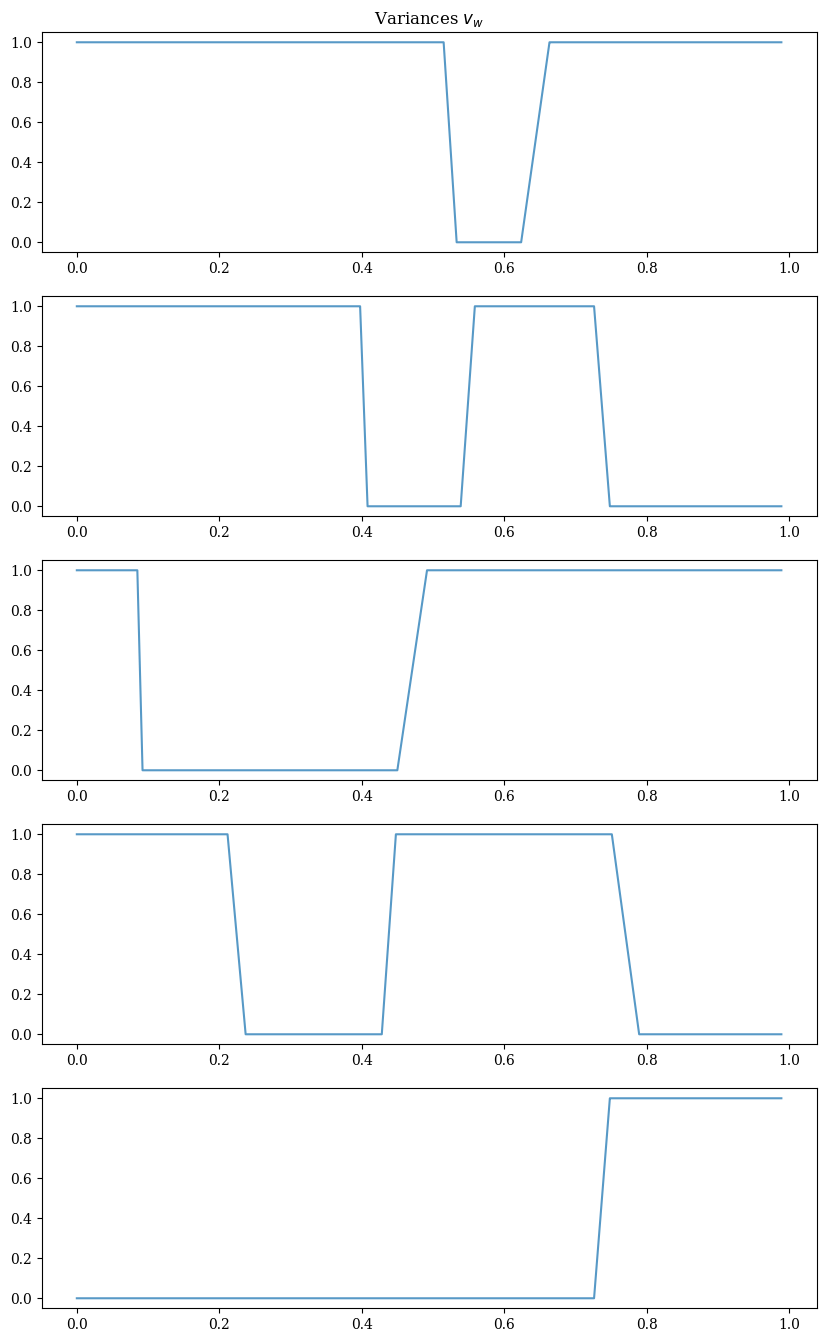

In [8]:
# We plot the annotators reliability as a function of the input features
plt.rc('text', usetex=False)
plt.rc('font', family='serif')
plt.figure(figsize=(10, 20))
for w in range(W):
    #Plots
    plt.subplot(6,1,w+1)
    plt.plot(Xtrain, Z_w[w], alpha=0.75, label='$v_'+str(w+1)+'$')
plt.subplot(6,1,1)
plt.title(r'Variances $v_w$')
plt.show()

In [9]:
#annotators performance
Acc = np.zeros((W+1,1))
for w in range(W):
    Acc[w,:] = accuracy_score(ytrain, Ytrain[:,w])
Acc[-1,:] = accuracy_score(ytrain, MAjVot(Ytrain, K))
NameCol = ['Accuracy']
NameIdx = ['Annotator_1','Annotator_2','Annotator_3','Annotator_4','Annotator_5','MajorityVoting']
Per = pd.DataFrame(Acc, columns =NameCol, index=NameIdx)
Per

,Accuracy
Annotator_1,0.88
Annotator_2,0.61
Annotator_3,0.59
Annotator_4,0.58
Annotator_5,0.24
MajorityVoting,0.80


In [10]:
train_dataset = torch.utils.data.TensorDataset(torch.tensor(Xtrain, dtype=torch.float32), torch.tensor(Ytrain - 1, dtype=torch.long))
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=100, shuffle=False)

## 4. Correlated Chained Gaussian Processes with Focal Loss for Multiple Annotators (CCGPFL)

We use the proposed CCGPFL framework to address multi-class classification problems with multiple annotators. The model builds on Correlated Chained Gaussian Processes for Multiple Annotators (CCGPMA), which estimates annotator-specific reliability as a function of the input features while capturing dependencies among annotators through correlated latent Gaussian processes. Unlike the original formulation, CCGPFL incorporates a focal-loss-based variational objective to reduce the dominance of frequent annotation patterns and improve learning when sparse annotation can generate clases imbalanced .

In [11]:
Q = K + W
J = K + W
M = 10

model, likelihood = build_ccgpma(
    num_classes=K,
    num_ann=W,
    inducing_p=M,
    num_latents=Q,
    input_dim=Xtrain.shape[1],
    initial_lengthscale=0.05,
    focal_gamma=0.1,
    num_likelihood_samples=200,
)


In [12]:
variational_ngd_optimizer = gpytorch.optim.NGD(model.variational_parameters(), num_data=Xtrain.shape[0], lr=0.01)

hyperparameter_optimizer = torch.optim.Adam([
    {'params': model.hyperparameters()},
    {'params': likelihood.parameters()},
], lr=0.005)

In [13]:
# We do this to use the GPU (if we only use CPU, the training will take a lot of time)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Assuming that we are on a CUDA machine, this should print a CUDA device:
print(device)

cuda:0


In [14]:
model.to(device)
likelihood.to(device)

MultiClassMA(
  (quadrature): GaussHermiteQuadrature1D()
)

In [15]:
model.train()
likelihood.train()
mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=Xtrain.shape[0])

logf = []
num_epochs = 2000
for i in range(num_epochs):

    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        ### Perform NGD step to optimize variational parameters
        variational_ngd_optimizer.zero_grad()
        hyperparameter_optimizer.zero_grad()

        output = model(x_batch)
        loss = -mll(output, y_batch)

        loss.backward()
        variational_ngd_optimizer.step()
        hyperparameter_optimizer.step()

    if i % 10 == 0:
      elbo = loss.item()
      logf.append(elbo)

/usr/local/lib/python3.12/dist-packages/linear_operator/utils/interpolation.py:66: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  summing_matrix = torch.sparse_coo_tensor(


Text(0, 0.5, 'ELBO')

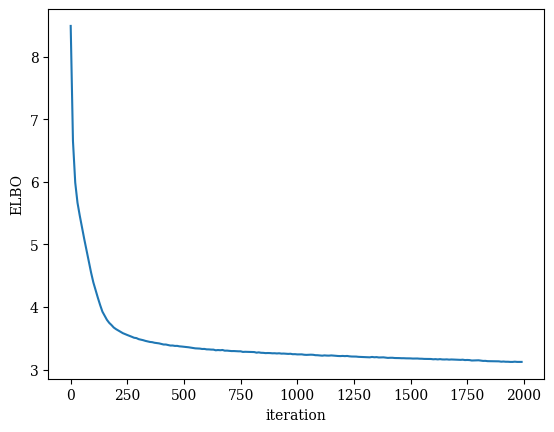

In [16]:
plt.plot(np.arange(num_epochs)[::10], logf)
plt.xlabel("iteration")
plt.ylabel("ELBO")

In [17]:
model.eval()
likelihood.eval()
Xtest = torch.tensor(Xtest, dtype=torch.float32).to(device)

In [18]:
with torch.no_grad():
    observed_pred = likelihood(model(Xtest))
    pY = observed_pred[0].cpu().numpy()
    pYv = observed_pred[1].cpu().numpy()

## 5. Figures  and Perfomance assessment

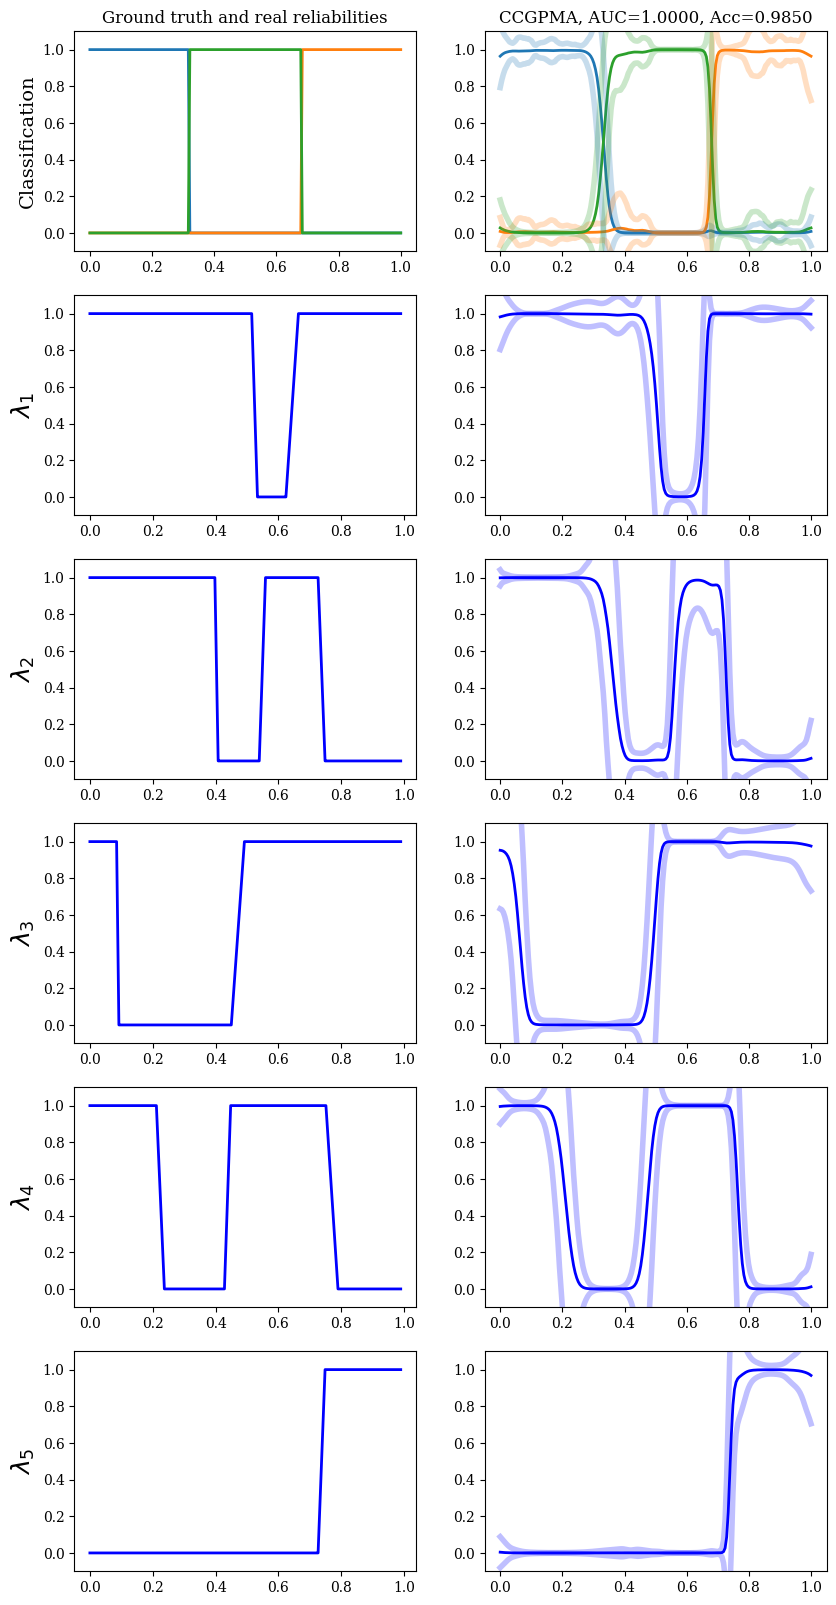

In [19]:
plt.rc('text', usetex=False)
plt.rc('font', family='serif')
plt.figure(figsize=(15, 20))

Mc, Vc = pY, abs(pYv)
M, V = pY, abs(pYv)
Yhat_test = one_of_K(ytest, K)

for w in range(W+1):
    # Original Values
    miny = 0
    maxy = 1
    if w ==0:
        plt.subplot(W+1,3, 3*w+1)
        plt.plot(Xtest.cpu(), Yhat_test, linewidth=2, alpha=1)
        plt.ylabel("Classification",fontsize=14)
        plt.ylim(miny-0.1, maxy+0.1)
    else:
        plt.subplot(W+1,3, 3*w+1)
        plt.plot(Xtrain, Z_w[w-1], 'b-', linewidth=2, alpha=1)
        plt.ylabel(r"$"+r"\lambda_"+str(w)+'$', fontsize=18)
        plt.ylim(-0.1, 1.1)

    # CGP
    if w > 0:
        mfc, vfc = Mc[:, K+w-1], Vc[:, K+w-1]
        mf_upperc = mfc + 2*np.sqrt(vfc)
        mf_lowerc = mfc - 2*np.sqrt(vfc)

        plt.subplot(W+1,3, 3*w+2)
        plt.plot(Xtest.cpu(), (mfc), 'b-', linewidth=2, alpha=1)
        plt.plot(Xtest.cpu(), (mf_upperc), 'b-', linewidth=4, alpha=0.25)
        plt.plot(Xtest.cpu(), (mf_lowerc), 'b-', linewidth=4, alpha=0.25)
        plt.ylim(-0.1, 1.1)
    else:
        mfc, vfc = Mc[:, :K], Vc[:, :K]
        mf_upperc = mfc + 2*np.sqrt(vfc)
        mf_lowerc = mfc - 2*np.sqrt(vfc)

        plt.subplot(W+1,3, 3*w+2)
        plt.plot(Xtest.cpu(), (mfc), linewidth=2, alpha=1)
        plt.gca().set_prop_cycle(None)
        plt.plot(Xtest.cpu(), (mf_upperc), linewidth=4, alpha=0.25)
        plt.gca().set_prop_cycle(None)
        plt.plot(Xtest.cpu(), (mf_lowerc), linewidth=4, alpha=0.25)
        plt.ylim(miny-0.1, maxy+0.1)



# Classification performance
auxMc = np.array(np.argmax(Mc[:,:K], 1).reshape(-1,1), dtype=float)+1
auxM = np.array(np.argmax(M[:,:K], 1).reshape(-1,1), dtype=float)+1

AccCGP = accuracy_score(ytest, auxMc)
AccCCGP = accuracy_score(ytest, auxM)
AUC_CGP = roc_auc_score(Yhat_test, Mc[:,:K])
AUC_CCGP = roc_auc_score(Yhat_test, M[:,:K])

plt.subplot(W+1,3,1)
plt.title('Ground truth and real reliabilities')
plt.subplot(W+1,3,2)
plt.title('CCGPMA, '+'AUC='+"{:.4f}".format(AUC_CGP)+', Acc='"{:.4f}".format(AccCGP))
plt.show()
